In [2]:
import os
import cv2
import time
import signal
import threading
import numpy as np
import pyzed.sl as sl
import matplotlib.pyplot as plt

### Record videos

In [25]:
zed_list = []
current_images = []
current_timestamps = []
thread_list = []
stop_signal = False




def signal_handler(signal, frame):
    global stop_signal
    stop_signal=True
    time.sleep(0.5)
    exit()

def grab_run(index):
    global stop_signal
    global zed_list
    global current_timestamps
    global current_images
    global name_list

    

    runtime = sl.RuntimeParameters()
    while not stop_signal:

        err = zed_list[index].grab(runtime)
        if err == sl.ERROR_CODE.SUCCESS:

            zed_list[index].retrieve_image(current_images[index], sl.VIEW.LEFT)
            current_timestamps[index] = zed_list[index].get_timestamp(sl.TIME_REFERENCE.CURRENT).data_ns #time of function call


        barrier.wait()

        time.sleep(0.001) #0.1ms
    zed_list[index].disable_recording()
    zed_list[index].close()

def main():
    global stop_signal
    global zed_list
    global current_images
    global current_timestamps
    global thread_list
    global name_list
    global barrier
    signal.signal(signal.SIGINT, signal_handler)

    output_file_names = ['multicam_1.svo2','multicam_2.svo2']

    print("Running...")
    init = sl.InitParameters()
    init.camera_resolution = sl.RESOLUTION.HD1080
    init.camera_fps = 60  # The framerate is lowered to avoid any USB3 bandwidth issues
    # init.async_image_retrieval = True


    #List and open cameras
    name_list = []
    last_ts_list = []
    cameras = sl.Camera.get_device_list()

    index = 0
    for cam in cameras:
        init.set_from_serial_number(cam.serial_number) # define input source
        name_list.append(f"ZED_{cam.serial_number}")

        print(f"Opening {name_list[index]}")
        zed_list.append(sl.Camera())
        current_images.append(sl.Mat())
        current_timestamps.append(0)
        last_ts_list.append(0)

        # open cameras
        status = zed_list[index].open(init)
        if status != sl.ERROR_CODE.SUCCESS:
            print(repr(status))
            zed_list[index].close()

        # set recording params
        recording_param = sl.RecordingParameters(
            os.path.join('./', output_file_names[index]),
            sl.SVO_COMPRESSION_MODE.H264) # Enable recording with the filename specified in argument
        err = zed_list[index].enable_recording(recording_param)
        index = index +1

        if err != sl.ERROR_CODE.SUCCESS:
            print("Recording ZED : ", err)
            exit(1)

    num_threads = len(zed_list)
    barrier = threading.Barrier(num_threads)

    #Start camera threads
    for index in range(0, len(zed_list)):
        if zed_list[index].is_opened():
            thread_list.append(threading.Thread(target=grab_run, args=(index,)))
            thread_list[index].start()
    
    #Display camera images
    key = ''
    while key != 113:  # for 'q' key
        for cam_index in range(0, len(zed_list)):
            if zed_list[cam_index].is_opened():

                # if there is a new frame 
                if (current_timestamps[cam_index] >= last_ts_list[cam_index]):
                    img = current_images[cam_index].get_data()

                    img = cv2.circle(img,(960,540),10,(0,0,255),3)
                    
                    cv2.imshow(name_list[cam_index], cv2.resize(img,(800,600)))

                    # set the last timestamp for each cam to the CURRENT_ts one of each cam 
                    last_ts_list[cam_index] = current_timestamps[cam_index]

        key = cv2.waitKey(10)
    cv2.destroyAllWindows()

    #Stop the threads
    stop_signal = True
    for index in range(0, len(thread_list)):
        thread_list[index].join()
    print("\nFINISH")

if __name__ == "__main__":
    main()

Running...
[2025-02-13 14:19:09 UTC][ZED][INFO] Logging level INFO
Opening ZED_43957242
[2025-02-13 14:19:09 UTC][ZED][INFO] Logging level INFO
[2025-02-13 14:19:10 UTC][ZED][INFO] Logging level INFO
[2025-02-13 14:19:10 UTC][ZED][INFO] Logging level INFO
[2025-02-13 14:19:10 UTC][ZED][INFO] Logging level INFO
[2025-02-13 14:19:10 UTC][ZED][INFO] [Init]  Depth mode: PERFORMANCE
[2025-02-13 14:19:15 UTC][ZED][INFO] [Init]  Camera FW version: 2001
[2025-02-13 14:19:15 UTC][ZED][INFO] [Init]  Video mode: HD1080@60
[2025-02-13 14:19:15 UTC][ZED][INFO] [Init]  Serial Number: S/N 43957242
[2025-02-13 14:19:16 UTC][ZED][INFO] [Init]  Notice: The recording is using SVO version 2, enabled by default starting from SDK version 4.1. To revert to the original SVO version, set the environment variable "ZED_SDK_SVO_VERSION" to 1
Opening in BLOCKING MODE 
Opening ZED_43916681


NvMMLiteOpen : Block : BlockType = 4 
===== NvVideo: NVENC =====
NvMMLiteBlockCreate : Block : BlockType = 4 
H264: Profile = 77, Level = 50 
NVMEDIA: Need to set EMC bandwidth : 5744000 


[2025-02-13 14:19:16 UTC][ZED][INFO] Logging level INFO
[2025-02-13 14:19:16 UTC][ZED][INFO] Logging level INFO
[2025-02-13 14:19:16 UTC][ZED][INFO] Logging level INFO
[2025-02-13 14:19:16 UTC][ZED][INFO] [Init]  Depth mode: PERFORMANCE
[2025-02-13 14:19:20 UTC][ZED][INFO] [Init]  Camera FW version: 2001
[2025-02-13 14:19:20 UTC][ZED][INFO] [Init]  Video mode: HD1080@60
[2025-02-13 14:19:20 UTC][ZED][INFO] [Init]  Serial Number: S/N 43916681
[2025-02-13 14:19:20 UTC][ZED][WARNING] [Init]  Self-calibration failed. Point the camera towards a more textured and brighter area. Avoid objects closer than 1 meter (Error code: 0x01) 
[2025-02-13 14:19:21 UTC][ZED][INFO] [Init]  Notice: The recording is using SVO version 2, enabled by default starting from SDK version 4.1. To revert to the original SVO version, set the environment variable "ZED_SDK_SVO_VERSION" to 1
Opening in BLOCKING MODE 


NvMMLiteOpen : Block : BlockType = 4 
===== NvVideo: NVENC =====
NvMMLiteBlockCreate : Block : BlockType = 4 
H264: Profile = 77, Level = 50 
NVMEDIA: Need to set EMC bandwidth : 5744000 
NvVideo: bBlitMode is set to TRUE 
NvVideo: bBlitMode is set to TRUE 



FINISH


### Extract timestamps and images from video

In [31]:
import os
import cv2
import pyzed.sl as sl
from Util.util import progress_bar

data = {"fn_timestamp": [], "img_timestamp": [], "imgs": [], "fps": []}


input_folder = "./stereo_videos"
input_file_name = "multicam_2.svo2"
filepath = os.path.join(input_folder, input_file_name)

input_type = sl.InputType()
input_type.set_from_svo_file(filepath)  # Set init parameter to run from the .svo
init = sl.InitParameters(input_t=input_type, svo_real_time_mode=False)

cam = sl.Camera()
status = cam.open(init)
if status != sl.ERROR_CODE.SUCCESS:  # Ensure the camera opened succesfully
    print("Camera Open", status, "Exit program.")
    exit(1)

# Set a maximum resolution, for visualisation confort
resolution = cam.get_camera_information().camera_configuration.resolution
low_resolution = sl.Resolution(min(720, resolution.width), min(404, resolution.height))


runtime = sl.RuntimeParameters()
nb_frames = cam.get_svo_number_of_frames()

print("[Info] SVO contains ", nb_frames, " frames")

cv2.namedWindow("View")

svo_image = sl.Mat()

while True:

    err = cam.grab(runtime)
    if err == sl.ERROR_CODE.SUCCESS:
        cam.retrieve_image(svo_image, sl.VIEW.LEFT, sl.MEM.CPU, low_resolution)

        # fn_timestamp = cam.get_timestamp(sl.TIME_REFERENCE.CURRENT).data_ns
        # img_timestamp = cam.get_timestamp(sl.TIME_REFERENCE.CURRENT).data_ns
        fps = cam.get_current_fps()

        # data["fn_timestamp"].append(fn_timestamp)
        # data["img_timestamp"].append(img_timestamp)
        data["img_timestamp"].append(svo_image.timestamp.get_nanoseconds())
        data["imgs"].append(svo_image.get_data().copy())
        data["fps"].append(fps)

        img = svo_image.get_data()
        cv2.waitKey(10)
        cv2.imshow("View", img)  # dislay both images to cv2
    else:
        print("Grab ZED : ", err)
        break

cv2.destroyAllWindows()
cam.close()

[Info] SVO contains  637  frames
Grab ZED :  END OF SVO FILE REACHED


In [32]:
convert_ns_to_datetime(svo_image.timestamp.get_nanoseconds())

datetime.datetime(2025, 2, 13, 14, 19, 39, 449506, tzinfo=datetime.timezone.utc)

### Process extracted data

In [33]:
import cv2

stored_timestamps = []

index = 0
while index < len(data['imgs']):
    img = data['imgs'][index]
    try:
        if img is not None and img.size > 0:
            cv2.imshow("Image View", img)
            key = cv2.waitKey(0)  # Wait for a key press to move to the next image
            if key == ord('+'):
                index += 1
            elif key == ord('-') and index > 0:
                index -= 1
            elif key == ord(' '):  # Spacebar pressed
                # fn_ts = data['fn_timestamp'][index]
                img_ts = data['img_timestamp'][index]
                stored_timestamps.append(img_ts)
                print(f"Stored timestamps for index: {index}, img_timestamp={img_ts}")
        else:
            print("Warning: Empty or None image encountered.")
    except cv2.error as e:
        print(f"OpenCV error: {e}")
    except Exception as e:
        print(f"Unexpected error: {e}")

cv2.destroyAllWindows()


Stored timestamps for index: 112, img_timestamp=1739456364532756000
Stored timestamps for index: 163, img_timestamp=1739456366016137000
Stored timestamps for index: 241, img_timestamp=1739456368166090000
Stored timestamps for index: 314, img_timestamp=1739456370232791000
Stored timestamps for index: 389, img_timestamp=1739456372332828000
Stored timestamps for index: 457, img_timestamp=1739456374282850000


In [34]:
stored_timestamps = np.array(stored_timestamps)
np.save("./cam2_ts.npy", stored_timestamps)

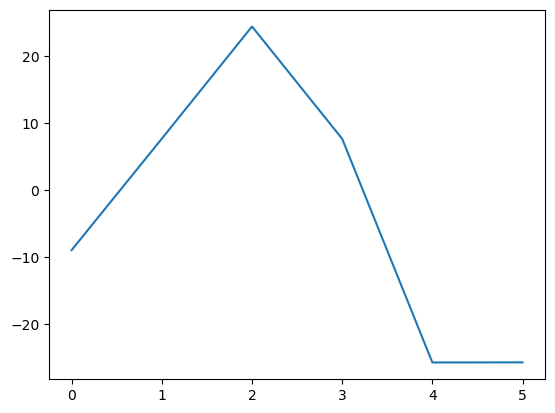

In [37]:
cam1_ts = np.load("./cam1_ts.npy")/1000000
cam2_ts = np.load("./cam2_ts.npy")/1000000

plt.plot(cam1_ts-cam2_ts)


In [ ]:
from datetime import datetime, timezone

# Convert nanoseconds to datetime
def convert_ns_to_datetime(ns):
    return datetime.fromtimestamp(ns / 1e9, tz=timezone.utc)

# Convert all timestamps in the data dictionary
data['fn_timestamp_dt'] = [convert_ns_to_datetime(ts) for ts in data['fn_timestamp']]
data['img_timestamp_dt'] = [convert_ns_to_datetime(ts) for ts in data['img_timestamp']]

# Print the first few converted timestamps to verify
print(data['fn_timestamp_dt'][:5])
print(data['img_timestamp_dt'][:5])

In [21]:
cam1_ts = [(convert_ns_to_datetime(ts[0]),convert_ns_to_datetime(ts[1])) for ts in np.load('./cam1_ts.npy')]
cam2_ts = [(convert_ns_to_datetime(ts[0]),convert_ns_to_datetime(ts[1])) for ts in np.load('./cam2_ts.npy')]

for t in cam2_ts[:10]:
    print(t)
print('\n')
for t in cam1_ts[:10]:
    print(t)

(datetime.datetime(2025, 2, 14, 9, 31, 6, 872294, tzinfo=datetime.timezone.utc), datetime.datetime(2025, 2, 14, 9, 31, 6, 872296, tzinfo=datetime.timezone.utc))
(datetime.datetime(2025, 2, 14, 9, 31, 10, 122382, tzinfo=datetime.timezone.utc), datetime.datetime(2025, 2, 14, 9, 31, 10, 122384, tzinfo=datetime.timezone.utc))
(datetime.datetime(2025, 2, 14, 9, 31, 15, 77989, tzinfo=datetime.timezone.utc), datetime.datetime(2025, 2, 14, 9, 31, 15, 77992, tzinfo=datetime.timezone.utc))
(datetime.datetime(2025, 2, 14, 9, 31, 19, 517214, tzinfo=datetime.timezone.utc), datetime.datetime(2025, 2, 14, 9, 31, 19, 517216, tzinfo=datetime.timezone.utc))
(datetime.datetime(2025, 2, 14, 9, 31, 24, 55415, tzinfo=datetime.timezone.utc), datetime.datetime(2025, 2, 14, 9, 31, 24, 55417, tzinfo=datetime.timezone.utc))
(datetime.datetime(2025, 2, 14, 9, 31, 28, 153130, tzinfo=datetime.timezone.utc), datetime.datetime(2025, 2, 14, 9, 31, 28, 153131, tzinfo=datetime.timezone.utc))


(datetime.datetime(2025, 2

#### Manual timestamps

In [ ]:
cam1_fn = np.array([1739461432213468817,
                    1739461674466071676,
                    1739461707246427225,
                    1739461744323333921,
                    1739461771631301163,
                    1739461801440064082])/1000000

cam1_img = np.array([1739461432213478993,
                     1739461674466082812,
                     1739461707246435801,
                     1739461744323342945,
                     1739461771631310379,
                     1739461801440074962])/1000000

cam2_fn = np.array([1739461856587684348,
                    1739461892295466039,
                    1739461925437439188,
                    1739461945978010036,
                    1739461966833438624,
                    1739461996298820297])/1000000

cam2_img = np.array([1739461856587692060,
                     1739461892295473271,
                     1739461925437444980,
                     1739461945978020596,
                     1739461966833445088,
                     1739461996298820297])/1000000